# Fine-tuning clasificador de especies de ECHO - sin crop

Este notebook entrena y evalúa el modelo usando la imagen  completa sin aplicar cropping con detector.

## 1. Setup

In [1]:
!pip -q install scikit-learn tqdm matplotlib pandas openpyxl

import os
import json
import zipfile
import random
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler

import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split

import re
import unicodedata
import openpyxl

from PIL import Image, ImageOps

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA disponible:", torch.cuda.is_available())

Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA disponible: True


In [19]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

## 2. Configuración general

In [ ]:
USE_GOOGLE_DRIVE = True
BUILD_DATASET_FROM_METADATA = True
# BUILD_DATASET_FROM_METADATA = False
DRIVE_SNAPSHOT_ROOT = "/content/drive/MyDrive/ECHO/snapshot_images"
DRIVE_METADATA_PATH = "/content/drive/MyDrive/ECHO/Metadata/detections_metadata.json"

# carpeta temporal
WORK_DIR = Path("/content/saviia_species_training_fullframe")
FULL_DATA_ROOT = WORK_DIR / "full_images_same_samples"
OUTPUT_DIR = WORK_DIR / "outputs_fullframe"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# configuraciones de entrenamiento del modelo
SEED = 42
IMG_SIZE = 224
VAL_SIZE = 0.20
BATCH_SIZE = 32
NUM_WORKERS = 2

PIN_MEMORY = True
USE_SYMLINKS = False
FORCE_REBUILD_FULL_DATASET = True


EPOCHS_HEAD = 5          # Etapa 1 - entrenar solo el clasificador final
EPOCHS_FINETUNE = 10     # Etapa 2 - fine-tuning de layer4 + clasificador
EPOCHS_FINETUNE_ALL = 3
EXTRA_FINETUNE_EPOCHS = 2
LR_FINETUNE_ALL = 1e-6
LR_HEAD = 3e-4
LR_FINETUNE = 3e-5
LR_RESUME = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
USE_WEIGHTED_SAMPLER = False

# archivos finales del modelo (pesos)
BEST_MODEL_PATH = OUTPUT_DIR / "resnet50_species_fullframe_best.pt"
LAST_MODEL_PATH = OUTPUT_DIR / "resnet50_species_fullframe_last.pt"
HISTORY_PATH = OUTPUT_DIR / "training_history_fullframe.csv"
CLASS_MAPPING_PATH = OUTPUT_DIR / "class_mapping_fullframe.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

## 3. Montar Drive y preparar dataset full-frame

In [4]:
# Montaje de Drive y preparación de paths
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

metadata_path = Path(DRIVE_METADATA_PATH)
snapshot_root = Path(DRIVE_SNAPSHOT_ROOT)

if not metadata_path.exists():
    raise FileNotFoundError(f"No se encontró metadata en: {metadata_path}")

if not snapshot_root.exists():
    raise FileNotFoundError(f"No se encontró snapshot_images en: {snapshot_root}")

print("Metadata encontrado:", metadata_path)
print("snapshot_images encontrado:", snapshot_root)

Mounted at /content/drive
Metadata encontrado: /content/drive/MyDrive/ECHO/Metadata/detections_metadata.json
snapshot_images encontrado: /content/drive/MyDrive/ECHO/snapshot_images


In [5]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def safe_symlink_or_copy(src: Path, dst: Path):
    """
    Copia la imagen a /content para evitar leer desde Google Drive durante training.
    """
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists():
        return "exists"

    shutil.copy2(src, dst)
    return "copy"


def build_fullframe_dataset_from_metadata(metadata_path: Path, output_root: Path):
    """
    Construye un ImageFolder con imágenes originales, usando las mismas muestras
    registradas en detections_metadata.json.

    Estructura final:
        output_root/class_id/imagen_original
    """
    if FORCE_REBUILD_FULL_DATASET and output_root.exists():
        print("Eliminando dataset anterior para reconstruirlo con copias locales...")
        shutil.rmtree(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    n_total = 0
    n_added = 0
    n_missing = 0
    n_non_image = 0

    for top_class_id, images in metadata.items():
        if not isinstance(images, dict):
            continue

        for img_name, item in tqdm(images.items(), desc=f"Clase {top_class_id}"):
            if not isinstance(item, dict):
                continue

            class_id = str(item.get("class_id", top_class_id))
            src = Path(item.get("source_img_path", ""))
            n_total += 1

            if src.suffix.lower() not in VALID_EXTENSIONS:
                n_non_image += 1
                continue

            if not src.exists():
                n_missing += 1
                continue

            dst = output_root / class_id / src.name
            status = safe_symlink_or_copy(src, dst)
            if status in {"symlink", "copy"}:
                n_added += 1

    print("Total registros metadata:", n_total)
    print("Imágenes agregadas:", n_added)
    print("No encontradas:", n_missing)
    print("Extensión no válida:", n_non_image)
    print("Dataset full-frame:", output_root)

    return output_root


def contains_images(path: Path) -> bool:
    return any(p.is_file() and p.suffix.lower() in VALID_EXTENSIONS for p in path.iterdir())


def is_imagefolder_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    return len(class_dirs) > 0 and any(contains_images(d) for d in class_dirs)


def find_imagefolder_root(base_dir: Path) -> Path:
    """Busca una carpeta con estructura clase/imagenes para usar ImageFolder."""
    if is_imagefolder_root(base_dir):
        return base_dir

    for p in base_dir.rglob("*"):
        if p.is_dir() and is_imagefolder_root(p):
            return p

    raise RuntimeError(
        "No se encontró una estructura compatible con ImageFolder. "
        "Se espera algo como: root/clase/img1.jpg, root/clase/img2.jpg, ..."
    )


if BUILD_DATASET_FROM_METADATA:
    DATA_ROOT = build_fullframe_dataset_from_metadata(metadata_path, FULL_DATA_ROOT)
else:
    DATA_ROOT = find_imagefolder_root(snapshot_root)

print("DATA_ROOT:", DATA_ROOT)
print("Carpetas de clase detectadas:", sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])[:30])

# eliminar .ipynb_checkpoints si aparecen
for p in DATA_ROOT.rglob(".ipynb_checkpoints"):
    if p.is_dir():
        shutil.rmtree(p, ignore_errors=True)

Clase 0:   0%|          | 0/499 [00:00<?, ?it/s]

Clase 1:   0%|          | 0/499 [00:00<?, ?it/s]

Clase 2:   0%|          | 0/500 [00:00<?, ?it/s]

Clase 3:   0%|          | 0/314 [00:00<?, ?it/s]

Clase 4:   0%|          | 0/500 [00:00<?, ?it/s]

...

Clase 17:   0%|          | 0/211 [00:00<?, ?it/s]

Clase 18:   0%|          | 0/255 [00:00<?, ?it/s]

Clase 19:   0%|          | 0/253 [00:00<?, ?it/s]

Clase 20:   0%|          | 0/226 [00:00<?, ?it/s]

Total registros metadata: 6147
Imágenes agregadas: 6147
No encontradas: 0
Extensión no válida: 0
Dataset full-frame: /content/saviia_species_training_fullframe/full_images_same_samples
DATA_ROOT: /content/saviia_species_training_fullframe/full_images_same_samples
Carpetas de clase detectadas: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
from tqdm import tqdm

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

bad_images = []

for img_path in tqdm(list(Path(DATA_ROOT).rglob("*")), desc="Revisando imágenes"):
    if img_path.suffix.lower() not in IMG_EXTENSIONS:
        continue

    try:
        with Image.open(img_path) as img:
            img = ImageOps.exif_transpose(img)
            img = img.convert("RGB")
            img.load() 
    except Exception as e:
        bad_images.append({
            "path": str(img_path),
            "error": str(e),
        })

bad_df = pd.DataFrame(bad_images)
print("Imágenes con error:", len(bad_df))
display(bad_df.head(20))

Revisando imágenes: 100%|██████████| 6168/6168 [03:58<00:00, 25.88it/s]

Imágenes con error: 0


""


In [21]:
for item in bad_images:
    path = Path(item["path"])
    if path.exists():
        path.unlink()

print("Imágenes malas eliminadas:", len(bad_images))

Imágenes malas eliminadas: 0


## 4. Cargar metadata y mapear

In [22]:
def load_class_id_to_name(metadata_path: Path) -> dict:
    if not metadata_path.exists():
        print("No se encontró metadata. Se usarán los IDs de carpeta como nombres de clase.")
        return {}

    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    class_id_to_name = {}

    # Estructura esperada:
    # {
    #   "0": {
    #     "image.png": {"class_id": "0", "class_name": "Hued hued", ...}
    #   },
    #   ...
    # }
    for top_key, value in metadata.items():
        if isinstance(value, dict):
            for _, item in value.items():
                if isinstance(item, dict):
                    class_id = str(item.get("class_id", top_key))
                    class_name = item.get("class_name")
                    if class_name:
                        class_id_to_name[class_id] = class_name

    return class_id_to_name

class_id_to_name = load_class_id_to_name(metadata_path)
print("Clases encontradas en metadata:", len(class_id_to_name))
class_id_to_name

Clases encontradas en metadata: 21


{'0': 'Hued hued',
 '1': 'Pudu',
 '2': 'Puma',
 '3': 'Guina',
 '4': 'Chucao',
 '5': 'Zorzal',
 '6': 'Caballo',
 '7': 'Chingue',
 '8': 'Guanaco',
 '9': 'Huemul',
 '10': 'Liebre europea',
 '11': 'Oveja',
 '12': 'Perro domestico',
 '13': 'Vaca',
 '14': 'Zorro culpeo',
 '15': 'Vison americano',
 '16': 'Quique',
 '17': 'Jabali',
 '18': 'Zorro chilla',
 '19': 'Conejo europeo',
 '20': 'Gato domestico'}

## 5. Datasets y split train-validation


In [24]:
weights = ResNet50_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

# ajustamos las imagenes para entrenamiento con resnet50

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


# transformaciones dataset de train y val
train_dataset_full = datasets.ImageFolder(root=DATA_ROOT, transform=base_transform)
val_dataset_full = datasets.ImageFolder(root=DATA_ROOT, transform=base_transform)

num_classes = len(train_dataset_full.classes)
print("Número de clases:", num_classes)
print("Número total de imágenes:", len(train_dataset_full))
print("class_to_idx:", train_dataset_full.class_to_idx)

Número de clases: 21
Número total de imágenes: 6147
class_to_idx: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '3': 14, '4': 15, '5': 16, '6': 17, '7': 18, '8': 19, '9': 20}


In [25]:
# mapeos internos del modelo
class_to_idx = train_dataset_full.class_to_idx
idx_to_class_id = {idx: class_id for class_id, idx in class_to_idx.items()}
idx_to_class_name = {
    idx: class_id_to_name.get(class_id, class_id)
    for idx, class_id in idx_to_class_id.items()
}

# conteo de imágenes por clase
all_targets = np.array([target for _, target in train_dataset_full.samples])
class_counts = Counter(all_targets)

class_table = pd.DataFrame([
    {
        "model_idx": idx,
        "class_id": idx_to_class_id[idx],
        "class_name": idx_to_class_name[idx],
        "n_images": class_counts[idx],
    }
    for idx in sorted(idx_to_class_id.keys())
]).sort_values("model_idx")

class_table

,model_idx,class_id,class_name,n_images
0,0,0,Hued hued,499
1,1,1,Pudu,499
2,2,10,Liebre europea,203
3,3,11,Oveja,204
4,4,12,Perro domestico,206
5,5,13,Vaca,217
6,6,14,Zorro culpeo,215
7,7,15,Vison americano,203
8,8,16,Quique,207
9,9,17,Jabali,211


In [26]:
indices = np.arange(len(train_dataset_full))
targets = np.array([target for _, target in train_dataset_full.samples])
# creacion de datasets
try:
    train_idx, val_idx = train_test_split(
        indices,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=targets,
    )
except ValueError as e:
    print("No se pudo hacer split estratificado. Se usará split aleatorio.")
    print("Detalle:", e)
    train_idx, val_idx = train_test_split(
        indices,
        test_size=VAL_SIZE,
        random_state=SEED,
        shuffle=True,
    )

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("% split train-val: ", VAL_SIZE)

Train: 4917
Validation: 1230
% split train-val:  0.2


In [27]:
# Balance de clases

def build_train_sampler(targets: np.ndarray, train_idx: np.ndarray):
    """ Balance de clases durante el entrenamiento """
    train_targets = targets[train_idx]
    counts = np.bincount(train_targets, minlength=num_classes)
    counts = np.maximum(counts, 1)
    class_weights = 1.0 / counts
    sample_weights = class_weights[train_targets]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
print("Usar balance de clases: ", USE_WEIGHTED_SAMPLER)
if USE_WEIGHTED_SAMPLER:
    train_sampler = build_train_sampler(targets, train_idx)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        num_workers=0,
        pin_memory=False,
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("Batches train:", len(train_loader))
print("Batches validation:", len(val_loader))

Usar balance de clases:  False
Batches train: 154
Batches validation: 39


## 6. Modelo ResNet50

Entrenamiento en dos etapas:

1. **Head training:** se congela la base de ResNet50 y se entrena solo la capa final.
2. **Fine-tuning:** se descongela `layer4` y la capa final para ajustar representaciones al dataset de especies.

In [28]:
def build_resnet50(num_classes: int) -> nn.Module:
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features
    # ultima capa
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_resnet50(num_classes=num_classes).to(DEVICE)
print(model.fc)

Linear(in_features=2048, out_features=21, bias=True)


In [29]:
def set_trainable_layers(model: nn.Module, stage: str):
    """ Control capas que se entrenan en cada etapa."""
    if stage == "head":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True

    elif stage == "finetune_layer4":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    elif stage == "all":
        for param in model.parameters():
            param.requires_grad = True

    else:
        raise ValueError(f"Stage no soportado: {stage}")


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [30]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """
    Entrenamiento del modelo y actualizacion de sus pesos
    """
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    progress = tqdm(loader, desc="train", leave=False)
    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        amp_device = "cuda" if device.type == "cuda" else "cpu"
        with autocast(device_type=amp_device, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        preds = logits.argmax(dim=1)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        running_total += batch_size

        progress.set_postfix({
            "loss": running_loss / max(running_total, 1),
            "acc": running_correct / max(running_total, 1),
        })

    return running_loss / running_total, running_correct / running_total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluacion del modelo con el conjunto de validacion
    """
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    progress = tqdm(loader, desc="val", leave=False)
    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        amp_device = "cuda" if device.type == "cuda" else "cpu"
        with autocast(device_type=amp_device, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        batch_size = labels.size(0)
        preds = logits.argmax(dim=1)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        running_total += batch_size

        progress.set_postfix({
            "loss": running_loss / max(running_total, 1),
            "acc": running_correct / max(running_total, 1),
        })

    return running_loss / running_total, running_correct / running_total

In [ ]:
def save_checkpoint(
    path: Path, model: nn.Module, history: list, best_val_acc: float, epoch_info: dict
):
    checkpoint = {
        "model_name": "resnet50",
        "num_classes": num_classes,
        "image_size": IMG_SIZE,
        "model_state_dict": model.state_dict(),
        "class_to_idx": class_to_idx,
        "idx_to_class_id": idx_to_class_id,
        "idx_to_class_name": idx_to_class_name,
        "class_id_to_name": class_id_to_name,
        "best_val_acc": best_val_acc,
        "history": history,
        "epoch_info": epoch_info,
    }
    torch.save(checkpoint, path)


def run_training_stage(
    model, stage_name: str, epochs: int, lr: float, history: list, best_val_acc: float
):
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(epochs, 1)
    )

    amp_device = "cuda" if DEVICE.type == "cuda" else "cpu"
    scaler = GradScaler(amp_device, enabled=(DEVICE.type == "cuda"))

    print(f"\n=== Etapa: {stage_name} ===")
    print("Parámetros entrenables:", count_trainable_params(model))

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        row = {
            "stage": stage_name,
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
        history.append(row)

        print(
            f"[{stage_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(
                BEST_MODEL_PATH,
                model,
                history,
                best_val_acc,
                {"stage": stage_name, "epoch": epoch},
            )
            print(
                f"Nuevo mejor modelo guardado en: {BEST_MODEL_PATH} | val_acc={best_val_acc:.4f}"
            )

        pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

    save_checkpoint(
        LAST_MODEL_PATH,
        model,
        history,
        best_val_acc,
        {"stage": stage_name, "epoch": epochs},
    )
    return history, best_val_acc

## 8. Entrenamiento

Usamos transfer learning con ResNet50 preentrenado, reemplazando su capa final por un clasificador adaptado a las 21 especies del dataset.

Inicialmente congelamos todas las capas de la red y entrenamos solo la capa final (fc).

Luego aplicamos fine-tuning parcial descongelando layer4 (ultimo bloque convolucional de ResNet50) junto con la capa final, donde entrenamos con las características mas específicas y de alto nivel

Es decir, tenemos 2 estapas
- Etapa 1: aprendemos a clasificar las especies usando ResNet50 congelada (head)

- Etapa 2: layer4 + head: ajustamos las features finales de ResNet50 a las imagenes

In [32]:
print("DEVICE:", DEVICE)
print("Modelo en:", next(model.parameters()).device)

DEVICE: cuda
Modelo en: cuda:0


In [33]:
!nvidia-smi

Mon Jun 29 16:09:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             30W /   70W |     571MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Configuraciones checkpoint
RESUME_FROM_CHECKPOINT = False
CHECKPOINT_TO_LOAD = BEST_MODEL_PATH
EXTRA_FINETUNE_EPOCHS = 2
LR_RESUME = 1e-5

if RESUME_FROM_CHECKPOINT and CHECKPOINT_TO_LOAD.exists():
    print(f"Cargando checkpoint desde: {CHECKPOINT_TO_LOAD}")

    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    history = checkpoint.get("history", [])
    best_val_acc = checkpoint.get("best_val_acc", 0.0)

    print("Checkpoint cargado correctamente.")
    print("Best val_acc anterior:", best_val_acc)
    print("Última info guardada:", checkpoint.get("epoch_info", {}))

    set_trainable_layers(model, stage="finetune_layer4")

    history, best_val_acc = run_training_stage(
        model=model,
        stage_name="finetune_layer4_resume_low_lr",
        epochs=EXTRA_FINETUNE_EPOCHS,
        lr=LR_RESUME,
        history=history,
        best_val_acc=best_val_acc,
    )

else:
    print("No se cargó checkpoint. Entrenando desde cero.")

    history = []
    best_val_acc = 0.0

    # Etapa 1: entrenar solo la capa final fc
    set_trainable_layers(model, stage="head")
    history, best_val_acc = run_training_stage(
        model=model,
        stage_name="head_fullframe",
        epochs=EPOCHS_HEAD,
        lr=LR_HEAD,
        history=history,
        best_val_acc=best_val_acc,
    )

    # Etapa 2: fine-tuning parcial de layer4 + fc
    set_trainable_layers(model, stage="finetune_layer4")
    history, best_val_acc = run_training_stage(
        model=model,
        stage_name="finetune_layer4_fullframe",
        epochs=EPOCHS_FINETUNE,
        lr=LR_FINETUNE,
        history=history,
        best_val_acc=best_val_acc,
    )

print("\nEntrenamiento completado.")
print("Mejor val_acc:", best_val_acc)
print("Mejor checkpoint:", BEST_MODEL_PATH)
print("Último checkpoint:", LAST_MODEL_PATH)
print("Historial:", HISTORY_PATH)
print("Mapeo de clases:", CLASS_MAPPING_PATH)

No se cargó checkpoint. Entrenando desde cero.

=== Etapa: head_fullframe ===
Parámetros entrenables: 43029


[head_fullframe] Epoch 01/5 | train_loss=2.4807 train_acc=0.3740 | val_loss=2.0650 val_acc=0.6520
Nuevo mejor modelo guardado en: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt | val_acc=0.6520


[head_fullframe] Epoch 02/5 | train_loss=1.8333 train_acc=0.6659 | val_loss=1.6144 val_acc=0.7423
Nuevo mejor modelo guardado en: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt | val_acc=0.7423


[head_fullframe] Epoch 03/5 | train_loss=1.5296 train_acc=0.7494 | val_loss=1.4316 val_acc=0.7756
Nuevo mejor modelo guardado en: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt | val_acc=0.7756


[head_fullframe] Epoch 04/5 | train_loss=1.4009 train_acc=0.7679 | val_loss=1.3728 val_acc=0.7927
Nuevo mejor modelo guardado en: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt | val_acc=0.7927


...

[finetune_layer4_fullframe] Epoch 06/10 | train_loss=0.4387 train_acc=0.9904 | val_loss=0.5106 val_acc=0.9585


[finetune_layer4_fullframe] Epoch 07/10 | train_loss=0.4278 train_acc=0.9927 | val_loss=0.5027 val_acc=0.9602
Nuevo mejor modelo guardado en: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt | val_acc=0.9602


[finetune_layer4_fullframe] Epoch 08/10 | train_loss=0.4153 train_acc=0.9947 | val_loss=0.4961 val_acc=0.9634
Nuevo mejor modelo guardado en: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt | val_acc=0.9634


[finetune_layer4_fullframe] Epoch 09/10 | train_loss=0.4129 train_acc=0.9963 | val_loss=0.4943 val_acc=0.9650
Nuevo mejor modelo guardado en: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt | val_acc=0.9650


[finetune_layer4_fullframe] Epoch 10/10 | train_loss=0.4110 train_acc=0.9967 | val_loss=0.4928 val_acc=0.9667
Nuevo mejor modelo guardado en: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt | val_acc=0.9667

Entrenamiento completado.
Mejor val_acc: 0.9666666666666667
Mejor checkpoint: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_best.pt
Último checkpoint: /content/saviia_species_training_fullframe/outputs_fullframe/resnet50_species_fullframe_last.pt
Historial: /content/saviia_species_training_fullframe/outputs_fullframe/training_history_fullframe.csv
Mapeo de clases: /content/saviia_species_training_fullframe/outputs_fullframe/class_mapping_fullframe.json


## 9. Training and validation loss


In [35]:
history_df = pd.read_csv(HISTORY_PATH)
display(history_df)

,stage,epoch,lr,train_loss,train_acc,val_loss,val_acc
0,head_fullframe,1,2.713525e-04,2.480666,0.374009,2.064962,0.652033
1,head_fullframe,2,1.963525e-04,1.833293,0.665853,1.614408,0.742276
2,head_fullframe,3,1.036475e-04,1.529613,0.749441,1.431573,0.775610
3,head_fullframe,4,2.864745e-05,1.400888,0.767948,1.372827,0.792683
4,head_fullframe,5,0.000000e+00,1.331958,0.794183,1.324892,0.788618
5,finetune_layer4_fullframe,1,2.926585e-05,0.986187,0.822859,0.798440,0.872358
6,finetune_layer4_fullframe,2,2.713525e-05,0.693590,0.916412,0.662827,0.917073
7,finetune_layer4_fullframe,3,2.381678e-05,0.571573,0.952817,0.600378,0.931707
8,finetune_layer4_fullframe,4,1.963525e-05,0.507079,0.973764,0.552933,0.949593
9,finetune_layer4_fullframe,5,1.500000e-05,0.461168,0.984137,0.526324,0.958537


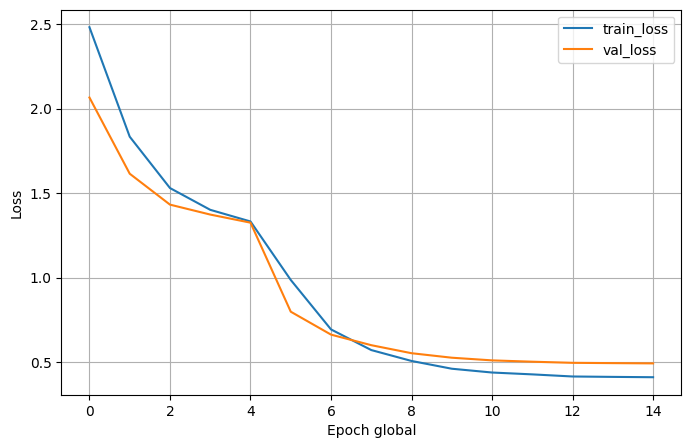

In [36]:
%matplotlib inline
plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch global")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

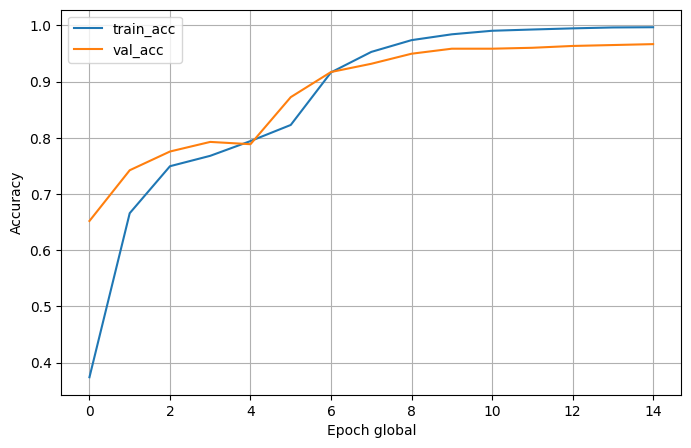

In [37]:
%matplotlib inline
plt.figure(figsize=(8, 5))
plt.plot(history_df["train_acc"], label="train_acc")
plt.plot(history_df["val_acc"], label="val_acc")
plt.xlabel("Epoch global")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 10. Mejor modelo full-frame

In [38]:
def load_trained_resnet50(checkpoint_path: Path, device: torch.device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = build_resnet50(num_classes=checkpoint["num_classes"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint

best_model, best_checkpoint = load_trained_resnet50(BEST_MODEL_PATH, DEVICE)
print("Modelo cargado correctamente.")
print("best_val_acc:", best_checkpoint["best_val_acc"])
print("idx_to_class_name:", best_checkpoint["idx_to_class_name"])

Modelo cargado correctamente.
best_val_acc: 0.9666666666666667
idx_to_class_name: {0: 'Hued hued', 1: 'Pudu', 2: 'Liebre europea', 3: 'Oveja', 4: 'Perro domestico', 5: 'Vaca', 6: 'Zorro culpeo', 7: 'Vison americano', 8: 'Quique', 9: 'Jabali', 10: 'Zorro chilla', 11: 'Conejo europeo', 12: 'Puma', 13: 'Gato domestico', 14: 'Guina', 15: 'Chucao', 16: 'Zorzal', 17: 'Caballo', 18: 'Chingue', 19: 'Guanaco', 20: 'Huemul'}


In [ ]:
DESTINATION_BEST_MODEL_PATH = "/content/drive/MyDrive/ECHO/Model/resnet50_species_fullframe_best.pt"

if BEST_MODEL_PATH.exists():
    shutil.copy2(BEST_MODEL_PATH, DESTINATION_BEST_MODEL_PATH)
    print("Modelo copiado a:", DESTINATION_BEST_MODEL_PATH)
else:
    print("No existe BEST_MODEL_PATH todavía:", BEST_MODEL_PATH)

Modelo copiado a: /content/drive/MyDrive/ECHO/Model/resnet50_species_fullframe_best.pt


# Testing full-frame / sin detector

## 1. Setup

In [40]:
!pip -q install scikit-learn openpyxl

import unicodedata
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt

In [ ]:
# Configuraciones generales de evaluación
EVAL_IMAGES_ZIP = Path("/content/drive/MyDrive/ECHO/Metadata/downloaded_eval_images.zip")
EVAL_IMAGES_DIR = Path("/content/eval_downloaded_images_fullframe")
EVAL_TEMPLATE_PATH = Path("/content/drive/MyDrive/ECHO/Metadata/Dataset_Evaluacion_EPII.xlsx")
EVAL_OUTPUT_PATH = Path("/content/drive/MyDrive/ECHO/Metadata/Plantilla_Evaluacion_Rellenada_fullframe.xlsx")
EVAL_OUTPUT_CSV = Path("/content/drive/MyDrive/ECHO/Metadata/predicciones_evaluacion_fullframe.csv")
SHEET_NAME = "Plantilla de Evaluación"

In [42]:
EVAL_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

if EVAL_IMAGES_ZIP.exists():
    with zipfile.ZipFile(EVAL_IMAGES_ZIP, "r") as zf:
        zf.extractall(EVAL_IMAGES_DIR)
    print("ZIP extraído en:", EVAL_IMAGES_DIR)
else:
    print("No se encontró ZIP. Se usará carpeta:", EVAL_IMAGES_DIR)



ZIP extraído en: /content/eval_downloaded_images_fullframe


## 2. Modelo clasificador full-frame

In [44]:
best_model.eval()
idx_to_class_name = {
    int(k): v for k, v in best_checkpoint["idx_to_class_name"].items()
}
print("Clases del modelo:", idx_to_class_name)
weights = ResNet50_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


Clases del modelo: {0: 'Hued hued', 1: 'Pudu', 2: 'Liebre europea', 3: 'Oveja', 4: 'Perro domestico', 5: 'Vaca', 6: 'Zorro culpeo', 7: 'Vison americano', 8: 'Quique', 9: 'Jabali', 10: 'Zorro chilla', 11: 'Conejo europeo', 12: 'Puma', 13: 'Gato domestico', 14: 'Guina', 15: 'Chucao', 16: 'Zorzal', 17: 'Caballo', 18: 'Chingue', 19: 'Guanaco', 20: 'Huemul'}


## 3. Utils del clasificador full-frame

In [46]:
"""
Utils classifier full-frame
"""
def normalize_text(text):
    text = "" if text is None else str(text)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    return text.lower().strip()


EVAL_SPECIES_MAP = {
    "guina": "Gato huiña",
    "gato huina": "Gato huiña",
    "gato huiña": "Gato huiña",
    "puma": "Puma",
    "zorzal": "Zorzal patagonico",
    "zorzal patagonico": "Zorzal patagonico",
    "chucao": "Chucao",
    "pudu": "Pudu",
    "hued hued": "Hued hued del sur",
    "hued hued del sur": "Hued hued del sur",
}


def to_eval_species(model_class_name):
    key = normalize_text(model_class_name)
    return EVAL_SPECIES_MAP.get(key, "Otro")


@torch.inference_mode()
def classify_full_image(img_path):
    with Image.open(img_path) as img:
        img = ImageOps.exif_transpose(img).convert("RGB")

    x = eval_transform(img).unsqueeze(0).to(DEVICE)

    logits = best_model(x)
    probs = torch.softmax(logits, dim=1)[0]

    pred_idx = int(torch.argmax(probs).item())
    pred_conf = float(probs[pred_idx].item())

    model_class_name = idx_to_class_name[pred_idx]
    eval_species = to_eval_species(model_class_name)

    return model_class_name, eval_species, pred_conf


def extract_excel_row_from_filename(img_path):
    # Ejemplo: row_0002__CAM6__1IZAOIR8S5BK.jpg -> 2
    match = re.search(r"row_(\d+)", img_path.stem)
    if not match:
        return None

    return int(match.group(1))

In [ ]:
# Cargamos la plantilla para rellenarla
if not EVAL_TEMPLATE_PATH.exists():
    candidates = list(
        Path(
            "/content/drive/MyDrive/ECHO/Protocolos/00_Evaluacion_SAVIIA_ML_Edge"
        ).glob("Dataset_Evaluacion_EPII*.xlsx")
    )
    candidates += list(Path("/content").glob("Dataset_Evaluacion_EPII*.xlsx"))

    if len(candidates) == 0:
        raise FileNotFoundError("No se encontró el Excel de evaluación.")

    EVAL_TEMPLATE_PATH = candidates[0]

print("Usando plantilla:", EVAL_TEMPLATE_PATH)

wb = openpyxl.load_workbook(EVAL_TEMPLATE_PATH)
ws = wb[SHEET_NAME]

headers = {ws.cell(row=1, column=col).value: col for col in range(1, ws.max_column + 1)}

detect_col = headers["¿Detectas un animal claro?"]
species_col = headers["Especie (Clasificación)"]


Usando plantilla: /content/drive/MyDrive/ECHO/Protocolos/00_Evaluacion_SAVIIA_ML_Edge/Dataset_Evaluacion_EPII.xlsx


In [ ]:
valid_exts = {".jpg", ".jpeg", ".png", ".webp"}

image_paths = sorted([
    p for p in EVAL_IMAGES_DIR.rglob("*")
    if p.suffix.lower() in valid_exts
])

print("Imágenes encontradas:", len(image_paths))

results = []

for img_path in tqdm(image_paths, desc="Evaluando imágenes full-frame"):
    excel_row = extract_excel_row_from_filename(img_path)

    if excel_row is None:
        continue

    # se clasifica directamente la imagen completa.
    animal_clear = "Si"
    model_class_name, eval_species, cls_conf = classify_full_image(img_path)

    ws.cell(row=excel_row, column=detect_col).value = animal_clear
    ws.cell(row=excel_row, column=species_col).value = eval_species

    results.append({
        "excel_row": excel_row,
        "image_path": str(img_path),
        "detecta_animal_claro": animal_clear,
        "especie_evaluacion": eval_species,
        "clase_modelo_original": model_class_name,
        "det_conf": None,
        "cls_conf": cls_conf,
        "bbox": None,
        "modo_evaluacion": "full_frame_sin_detector",
    })

Imágenes encontradas: 77


Evaluando imágenes full-frame: 100%|██████████| 77/77 [00:03<00:00, 19.85it/s]


In [49]:
wb.save(EVAL_OUTPUT_PATH)
results_df = pd.DataFrame(results).sort_values("excel_row")
results_df.to_csv(EVAL_OUTPUT_CSV, index=False)
print("Excel rellenado:", EVAL_OUTPUT_PATH)
print("CSV predicciones:", EVAL_OUTPUT_CSV)
display(results_df.head(20))
print(results_df["detecta_animal_claro"].value_counts(dropna=False))
print(results_df["especie_evaluacion"].value_counts(dropna=False))

Excel rellenado: /content/drive/MyDrive/ECHO/Metadata/Plantilla_Evaluacion_Rellenada_fullframe.xlsx
CSV predicciones: /content/drive/MyDrive/ECHO/Metadata/predicciones_evaluacion_fullframe.csv


,excel_row,image_path,detecta_animal_claro,especie_evaluacion,clase_modelo_original,det_conf,cls_conf,bbox,modo_evaluacion
0,2,/content/eval_downloaded_images_fullframe/row_...,Si,Pudu,Pudu,None,0.347456,None,full_frame_sin_detector
1,3,/content/eval_downloaded_images_fullframe/row_...,Si,Pudu,Pudu,None,0.748084,None,full_frame_sin_detector
2,4,/content/eval_downloaded_images_fullframe/row_...,Si,Pudu,Pudu,None,0.536028,None,full_frame_sin_detector
3,5,/content/eval_downloaded_images_fullframe/row_...,Si,Pudu,Pudu,None,0.354121,None,full_frame_sin_detector
4,6,/content/eval_downloaded_images_fullframe/row_...,Si,Hued hued del sur,Hued hued,None,0.183908,None,full_frame_sin_detector
5,7,/content/eval_downloaded_images_fullframe/row_...,Si,Gato huiña,Guina,None,0.324243,None,full_frame_sin_detector
6,8,/content/eval_downloaded_images_fullframe/row_...,Si,Chucao,Chucao,None,0.404298,None,full_frame_sin_detector
7,9,/content/eval_downloaded_images_fullframe/row_...,Si,Otro,Quique,None,0.462505,None,full_frame_sin_detector
8,10,/content/eval_downloaded_images_fullframe/row_...,Si,Hued hued del sur,Hued hued,None,0.250897,None,full_frame_sin_detector
9,11,/content/eval_downloaded_images_fullframe/row_...,Si,Puma,Puma,None,0.271677,None,full_frame_sin_detector


detecta_animal_claro
Si    77
Name: count, dtype: int64
especie_evaluacion
Pudu                 29
Gato huiña           17
Hued hued del sur    11
Otro                  6
Puma                  5
Zorzal patagonico     5
Chucao                4
Name: count, dtype: int64


## 4. Métricas de evaluación del clasificador full-frame

In [50]:
# cargamos el excel de verdad absoluta.
GT_EXCEL_PATH = EVAL_TEMPLATE_PATH
GT_SHEET_NAME = "Ground Truth Dataset"
if "results_df" not in globals():
    results_df = pd.read_csv(EVAL_OUTPUT_CSV)


In [51]:
"""
Utils
"""
def norm_text(x):
    if pd.isna(x):
        return ""

    x = str(x).strip()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    x = x.lower().strip()
    return x

def canonical_species(x):
    key = norm_text(x)
    if key == "":
        return None
    return SPECIES_CANONICAL_MAP.get(key, "Unknown")


def is_detected(x):
    key = norm_text(x)
    return key in {"si", "sí", "yes", "true", "1"}



In [52]:
# mapeo de especies (compatibilidad con el excel)
SPECIES_CANONICAL_MAP = {
    "chucao": "Chucao",

    "gato huina": "Gato huiña",
    "gato huiña": "Gato huiña",
    "guina": "Gato huiña",

    "hued hued": "Hued hued del sur",
    "hued hued del sur": "Hued hued del sur",

    "pudu": "Pudú",
    "pudú": "Pudú",

    "puma": "Puma",

    "zorzal": "Zorzal patagónico",
    "zorzal patagonico": "Zorzal patagónico",
    "zorzal patagónico": "Zorzal patagónico",

    "unknown": "Unknown",
    "otro": "Unknown",
}

In [53]:
gt_df = pd.read_excel(GT_EXCEL_PATH, sheet_name=GT_SHEET_NAME)
gt_df["excel_row"] = gt_df.index + 2
gt_df["gt_label"] = gt_df["Common Name"].apply(canonical_species)


In [54]:
def build_combined_pred(row):
    if not row["pred_detected"]:
        return "No detectado"

    if row["pred_species"] is None:
        return "Sin respuesta"

    return row["pred_species"]

pred_df = results_df.copy()
pred_df["pred_detected"] = pred_df["detecta_animal_claro"].apply(is_detected)
pred_df["pred_species"] = pred_df["especie_evaluacion"].apply(canonical_species)
pred_df["pred_combined_label"] = pred_df.apply(build_combined_pred, axis=1)


In [55]:
eval_df = gt_df.merge(
    pred_df,
    on="excel_row",
    how="inner",
)
eval_df["gt_combined_label"] = eval_df["gt_label"]
print("Filas evaluadas:", len(eval_df))


Filas evaluadas: 77


### Resultados generales

In [59]:
# Cargamos los labels ground truth y predicciones
y_true = eval_df["gt_combined_label"]
y_pred = eval_df["pred_combined_label"]

# Accuracy general usando etiqueta combinada
overall_accuracy = accuracy_score(y_true, y_pred)

# Detección: en este experimento se marca "Si" por diseño porque no hay imágenes vacías.
detection_score = eval_df["pred_detected"].mean()

# Accuracy clasificación pura
cls_eval_df = eval_df[
    (eval_df["pred_detected"] == True) &
    (eval_df["pred_species"].notna())
].copy()

if len(cls_eval_df) > 0:
    pure_classification_accuracy = accuracy_score(
        cls_eval_df["gt_label"],
        cls_eval_df["pred_species"],
    )
else:
    pure_classification_accuracy = np.nan

# F1 scores usando etiqueta combinada
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)


metrics = {
    "modo_evaluacion": "full_frame_sin_detector",
    "n": len(eval_df),
    "Accuracy": overall_accuracy,
    "Deteccion": detection_score,
    "Acc_clasificacion_pura": pure_classification_accuracy,
    "F1_macro": f1_macro,
    "F1_micro": f1_micro,
    "F1_weighted": f1_weighted,
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

,modo_evaluacion,n,Accuracy,Deteccion,Acc_clasificacion_pura,F1_macro,F1_micro,F1_weighted
0,full_frame_sin_detector,77,0.233766,1.0,0.233766,0.202938,0.233766,0.202938


### Resultados por clase

In [57]:
# Reporte de evaluacion por clase
report_dict = classification_report(
    y_true,
    y_pred,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

,precision,recall,f1-score,support
Chucao,0.000000,0.000000,0.000000,11.000000
Gato huiña,0.176471,0.272727,0.214286,11.000000
Hued hued del sur,0.363636,0.363636,0.363636,11.000000
Pudú,0.241379,0.636364,0.350000,11.000000
Puma,0.400000,0.181818,0.250000,11.000000
Unknown,0.166667,0.090909,0.117647,11.000000
Zorzal patagónico,0.200000,0.090909,0.125000,11.000000
accuracy,0.233766,0.233766,0.233766,0.233766
macro avg,0.221165,0.233766,0.202938,77.000000
weighted avg,0.221165,0.233766,0.202938,77.000000


### Matriz de confusion


,Chucao,Gato huiña,Hued hued del sur,Pudú,Puma,Unknown,Zorzal patagónico
Chucao,0,5,4,1,0,1,0
Gato huiña,0,3,1,6,0,1,0
Hued hued del sur,2,2,4,1,0,0,2
Pudú,0,1,0,7,0,1,2
Puma,0,3,0,6,2,0,0
Unknown,2,2,2,2,2,1,0
Zorzal patagónico,0,1,0,6,1,2,1


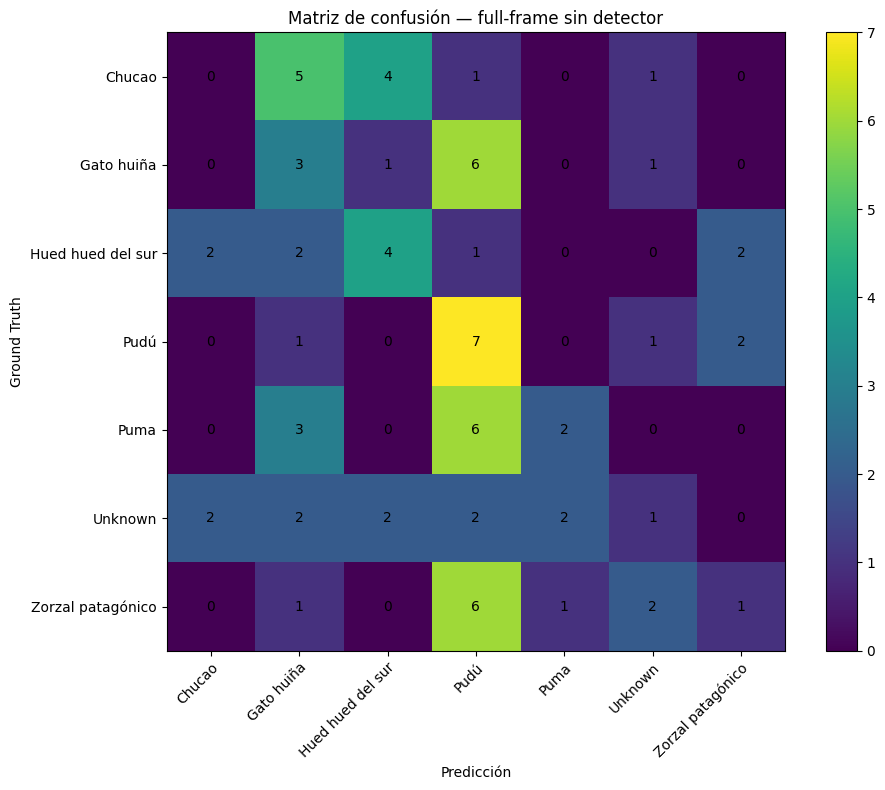

In [58]:
# Matriz de confusión
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest")
plt.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(labels)),
    yticks=np.arange(len(labels)),
    xticklabels=labels,
    yticklabels=labels,
    xlabel="Predicción",
    ylabel="Ground Truth",
    title="Matriz de confusión — full-frame sin detector"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
threshold = cm.max() / 2.0 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
        )

plt.tight_layout()
plt.show()

In [ ]:
MODEL_EVAL_DIR = Path("/content/drive/MyDrive/ECHO/Model_Evaluation")
MODEL_EVAL_DIR.mkdir(parents=True, exist_ok=True)

METRICS_OUTPUT_PATH = MODEL_EVAL_DIR / "metricas_modelo_eval_fullframe.csv"
REPORT_OUTPUT_PATH = MODEL_EVAL_DIR / "reporte_clases_modelo_eval_fullframe.csv"
CONFUSION_OUTPUT_PATH = MODEL_EVAL_DIR / "matriz_confusion_modelo_eval_fullframe.csv"
EVAL_ROWS_OUTPUT_PATH = MODEL_EVAL_DIR / "eval_rows_modelo_fullframe.csv"

metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
report_df.to_csv(REPORT_OUTPUT_PATH)
cm_df.to_csv(CONFUSION_OUTPUT_PATH)
eval_df.to_csv(EVAL_ROWS_OUTPUT_PATH, index=False)

print("Métricas guardadas en:", METRICS_OUTPUT_PATH)
print("Reporte por clase guardado en:", REPORT_OUTPUT_PATH)
print("Matriz de confusión guardada en:", CONFUSION_OUTPUT_PATH)
print("Filas evaluadas guardadas en:", EVAL_ROWS_OUTPUT_PATH)

Métricas guardadas en: /content/drive/MyDrive/ECHO/Model_Evaluation/metricas_modelo_eval.csv
Reporte por clase guardado en: /content/drive/MyDrive/ECHO/Model_Evaluation/reporte_clases_modelo_eval.csv
Filas evaluadas guardadas en: /content/drive/MyDrive/ECHO/Model_Evaluation/eval_rows_modelo.csv
